# Week 10 — Multivariate Gaussian Score and Conditioning

**Mode:** experiment

**Status:** completed experiment

**Question:** Do the multivariate Gaussian score and block-conditioning
formulas agree with numerical derivatives and empirical samples?

This notebook reuses the same example from the Week 10 proof:

$$
\mu=
\begin{bmatrix}
0\\
0
\end{bmatrix},
\qquad
\Sigma=
\begin{bmatrix}
2&1\\
1&1
\end{bmatrix}.
$$


## Reading map and success criteria

Use these only when you get stuck:

- [Week 10 theory note](../notes/w10_mml_multivariate_gaussian.md)
- [Score and conditioning proof](../proofs/w10_multivariate_gaussian_score.md)
- [Gaussian identities](../notes/gaussian_identities.md)

By the end, you should have checked that:

1. Cholesky samples reproduce $\mu$ and $\Sigma$.
2. The analytic score agrees with a central finite difference.
3. A thin empirical slice near $X_2=2$ has mean and variance close to
   the analytic conditional values $2$ and $1$.
4. The same score identity produces the score of a diffusion
   forward-noising kernel.

The three implementation checkpoints, plots, and numerical diagnostics
below record the completed experiment.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

config = {
    "seed": 10,
    "n_samples": 250_000,
    "n_plot_samples": 5_000,
    "conditional_bandwidth": 0.06,
    "finite_difference_epsilon": 1e-5,
}
rng = np.random.default_rng(config["seed"])

mu = np.array([0.0, 0.0])
Sigma = np.array(
    [
        [2.0, 1.0],
        [1.0, 1.0],
    ]
)
x2_observed = 2.0

eigenvalues = np.linalg.eigvalsh(Sigma)
assert mu.shape == (2,)
assert Sigma.shape == (2, 2)
assert np.allclose(Sigma, Sigma.T)
assert np.all(eigenvalues > 0)

{"mu": mu, "Sigma": Sigma, "eigenvalues": eigenvalues}


{'mu': array([0., 0.]),
 'Sigma': array([[2., 1.],
        [1., 1.]]),
 'eigenvalues': array([0.382, 2.618])}

---

## 1. Sample the Gaussian

If $Z\sim\mathcal{N}(0,I)$ and $\Sigma=LL^\top$, then

$$
X=\mu+LZ\sim\mathcal{N}(\mu,\Sigma).
$$

NumPy returns samples by row, so the implementation uses
$ZL^\top+\mu$.


In [2]:
L = np.linalg.cholesky(Sigma)
standard_samples = rng.standard_normal((config["n_samples"], 2))
samples = mu + standard_samples @ L.T

empirical_mean = samples.mean(axis=0)
empirical_cov = np.cov(samples, rowvar=False, ddof=1)

assert np.allclose(L @ L.T, Sigma)
assert np.allclose(empirical_mean, mu, atol=0.015)
assert np.allclose(empirical_cov, Sigma, atol=0.02)

{
    "Cholesky factor": L,
    "empirical mean": empirical_mean,
    "empirical covariance": empirical_cov,
}


{'Cholesky factor': array([[1.4142, 0.    ],
        [0.7071, 0.7071]]),
 'empirical mean': array([-0.0013, -0.003 ]),
 'empirical covariance': array([[2.0018, 1.0016],
        [1.0016, 1.0033]])}

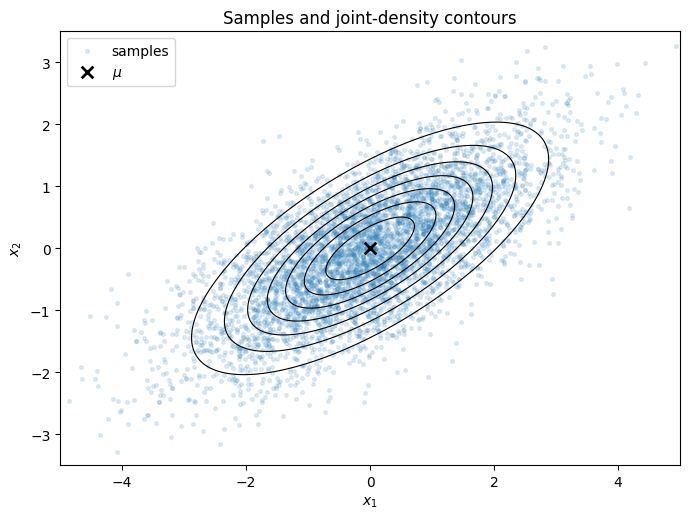

In [3]:
def gaussian_logpdf(points, mean, cov):
    '''Evaluate a multivariate Gaussian log-density at one or more points.'''
    points_array = np.asarray(points, dtype=float)
    was_one_point = points_array.ndim == 1
    points_2d = np.atleast_2d(points_array)
    centered = points_2d - mean

    sign, log_determinant = np.linalg.slogdet(cov)
    if sign <= 0:
        raise ValueError("cov must be positive definite")

    solved = np.linalg.solve(cov, centered.T).T
    quadratic = np.sum(centered * solved, axis=1)
    dimension = mean.size
    values = -0.5 * (
        dimension * np.log(2.0 * np.pi) + log_determinant + quadratic
    )
    return float(values[0]) if was_one_point else values


x1_axis = np.linspace(-5.0, 5.0, 190)
x2_axis = np.linspace(-3.5, 3.5, 170)
x1_mesh, x2_mesh = np.meshgrid(x1_axis, x2_axis)
density_points = np.column_stack((x1_mesh.ravel(), x2_mesh.ravel()))
joint_density = np.exp(gaussian_logpdf(density_points, mu, Sigma)).reshape(
    x1_mesh.shape
)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(
    samples[: config["n_plot_samples"], 0],
    samples[: config["n_plot_samples"], 1],
    s=7,
    alpha=0.13,
    color="tab:blue",
    label="samples",
)
ax.contour(x1_mesh, x2_mesh, joint_density, levels=9, colors="black", linewidths=0.8)
ax.scatter(*mu, color="black", marker="x", s=70, linewidths=2, label=r"$\mu$")
ax.set(
    title="Samples and joint-density contours",
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xlim=(-5.0, 5.0),
    ylim=(-3.5, 3.5),
)
ax.set_aspect("equal")
ax.legend()
fig.tight_layout()
plt.show()


**Checkpoint 1.** The sample cloud should form a tilted ellipse. Its
empirical mean and covariance should be close to the configured
parameters, with small Monte Carlo error.


---

## 2. Analytic score field

The score of a multivariate Gaussian is

$$
s(x)=\nabla_x\log p(x)=-\Sigma^{-1}(x-\mu).
$$

Implement this with a linear solve. If points are stored by row, solve
against the transpose of the centered array and transpose the result
back.


### Analytic score implementation

The function below accepts either one point with shape $(2,)$ or several
points with shape $(n,2)$.


In [5]:
def gaussian_score(points, mean, cov):
    '''Return the analytic score at one point or a batch of row-wise points.'''
    points_array = np.asarray(points, dtype=float)
    was_one_point = points_array.ndim == 1
    points_2d = np.atleast_2d(points_array)
    centered = points_2d - mean

    # Solve the precision-weighted displacement without forming cov^{-1}.
    scores = -np.linalg.solve(cov, centered.T).T

    return scores[0] if was_one_point else scores


score_probe_points = np.array(
    [
        [0.0, 0.0],
        [3.0, 2.0],
        [-1.0, 0.5],
    ]
)
score_probe_values = gaussian_score(score_probe_points, mu, Sigma)

if np.isfinite(score_probe_values).all():
    assert score_probe_values.shape == score_probe_points.shape
    assert np.allclose(gaussian_score(mu, mu, Sigma), np.zeros(2))
    assert np.allclose(gaussian_score(np.array([3.0, 2.0]), mu, Sigma), [-1.0, -1.0])
    print("score probes:\n", score_probe_values)
else:
    print("The analytic score returned non-finite values.")


score probes:
 [[-0.  -0. ]
 [-1.  -1. ]
 [ 1.5 -2. ]]


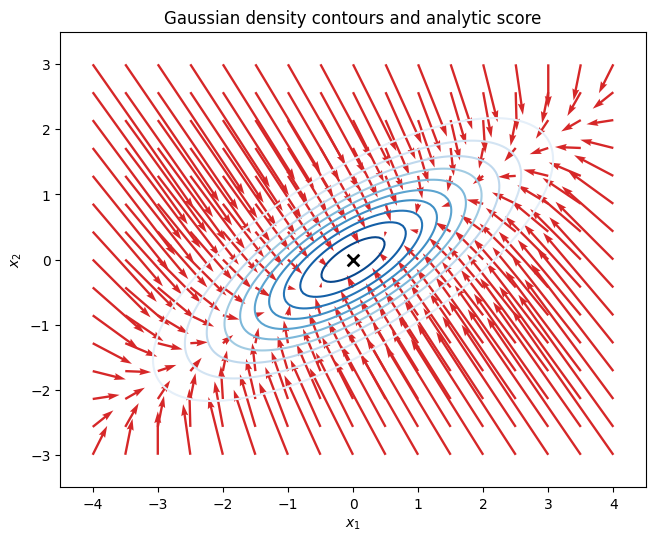

In [6]:
score_x1 = np.linspace(-4.0, 4.0, 17)
score_x2 = np.linspace(-3.0, 3.0, 15)
score_x1_mesh, score_x2_mesh = np.meshgrid(score_x1, score_x2)
score_grid_points = np.column_stack(
    (score_x1_mesh.ravel(), score_x2_mesh.ravel())
)
score_grid_values = gaussian_score(score_grid_points, mu, Sigma)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contour(x1_mesh, x2_mesh, joint_density, levels=10, cmap="Blues")

if np.isfinite(score_grid_values).all():
    ax.quiver(
        score_grid_points[:, 0],
        score_grid_points[:, 1],
        score_grid_values[:, 0],
        score_grid_values[:, 1],
        color="tab:red",
        angles="xy",
        scale_units="xy",
        scale=4.5,
        width=0.004,
    )
else:
    ax.text(
        0.5,
        0.5,
        "The analytic score is unavailable",
        transform=ax.transAxes,
        ha="center",
        va="center",
        bbox={"facecolor": "white", "alpha": 0.9},
    )

ax.scatter(*mu, color="black", marker="x", s=70, linewidths=2)
ax.set(
    title="Gaussian density contours and analytic score",
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xlim=(-4.5, 4.5),
    ylim=(-3.5, 3.5),
)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


**Checkpoint 2.** The vectors point toward higher density and cross each
contour normally. At the mean, the
score is zero.


---

## 3. Verify the score numerically

For coordinate $i$, use the central difference

$$
\frac{\partial}{\partial x_i}\log p(x)
\approx
\frac{\log p(x+\varepsilon e_i)-\log p(x-\varepsilon e_i)}
{2\varepsilon}.
$$


### Numerical score implementation

This implementation perturbs one coordinate at a time and uses
gaussian_logpdf independently of gaussian_score.


In [11]:
def numerical_score(point, mean, cov, epsilon=1e-5):
    '''Approximate the score with coordinate-wise central differences.'''
    point = np.asarray(point, dtype=float)
    approximation = np.zeros_like(point)

    for i in range(point.size):
        point_plus = point.copy()
        point_minus = point.copy()

        # Perturb the i-th coordinate
        point_plus[i] += epsilon
        point_minus[i] -= epsilon

        # Compute the log-density on both sides of the point.
        log_density_plus = gaussian_logpdf(point_plus, mean, cov)
        log_density_minus = gaussian_logpdf(point_minus, mean, cov)

        approximation[i] = (log_density_plus - log_density_minus) / (2.0 * epsilon)

    return approximation


comparison_points = np.array(
    [
        [0.0, 0.0],
        [3.0, 2.0],
        [-1.0, 0.5],
        [0.5, -1.0],
    ]
)
analytic_values = gaussian_score(comparison_points, mu, Sigma)
numerical_values = np.vstack(
    [
        numerical_score(
            point,
            mu,
            Sigma,
            epsilon=config["finite_difference_epsilon"],
        )
        for point in comparison_points
    ]
)

if np.isfinite(analytic_values).all() and np.isfinite(numerical_values).all():
    error_norms = np.linalg.norm(analytic_values - numerical_values, axis=1)
    assert error_norms.max() < 1e-5

    comparison = [
        {
            "point": point,
            "analytic": analytic,
            "numerical": numerical,
            "error norm": error,
        }
        for point, analytic, numerical, error in zip(
            comparison_points,
            analytic_values,
            numerical_values,
            error_norms,
        )
    ]
    print(f"maximum score error: {error_norms.max():.3e}")
    for row in comparison:
        print(row)
else:
    print("The score comparison contains non-finite values.")


maximum score error: 6.348e-11
{'point': array([0., 0.]), 'analytic': array([-0., -0.]), 'numerical': array([0., 0.]), 'error norm': np.float64(0.0)}
{'point': array([3., 2.]), 'analytic': array([-1., -1.]), 'numerical': array([-1., -1.]), 'error norm': np.float64(6.348345832214633e-11)}
{'point': array([-1. ,  0.5]), 'analytic': array([ 1.5, -2. ]), 'numerical': array([ 1.5, -2. ]), 'error norm': np.float64(1.637787683347068e-11)}
{'point': array([ 0.5, -1. ]), 'analytic': array([-1.5,  2.5]), 'numerical': array([-1.5,  2.5]), 'error norm': np.float64(1.1424065720322886e-11)}


**Checkpoint 3.** The maximum error should be tiny. If it is not, first
check that the finite difference is applied to the log-density rather
than to the density.


---

## 4. Verify Gaussian conditioning with samples

For a jointly Gaussian partition $(X_A,X_B)$,

$$
\mu_{A\mid B}
=
\mu_A+\Sigma_{AB}\Sigma_{BB}^{-1}(x_B-\mu_B),
$$

$$
\Sigma_{A\mid B}
=
\Sigma_{AA}-\Sigma_{AB}\Sigma_{BB}^{-1}\Sigma_{BA}.
$$

The implementation below keeps every block two-dimensional, even for
this scalar-on-scalar example. Compute the gain without explicitly
forming $\Sigma_{BB}^{-1}$.


### Block conditional implementation

The implementation computes the gain $K$ using the shape identity

$$
K\Sigma_{BB}=\Sigma_{AB},
\qquad
K\in\mathbb{R}^{|A|\times|B|}.
$$

NumPy solves systems of the form $MY=N$, so the code transposes this
equation and then transposes the result back.


In [12]:
def conditional_gaussian(mean, cov, a_indices, b_indices, x_b):
    '''Return the mean and covariance of X_A given X_B=x_b.'''
    a_indices = np.asarray(a_indices, dtype=int)
    b_indices = np.asarray(b_indices, dtype=int)
    x_b = np.asarray(x_b, dtype=float)

    mu_a = mean[a_indices]
    mu_b = mean[b_indices]
    sigma_aa = cov[np.ix_(a_indices, a_indices)]
    sigma_ab = cov[np.ix_(a_indices, b_indices)]
    sigma_ba = cov[np.ix_(b_indices, a_indices)]
    sigma_bb = cov[np.ix_(b_indices, b_indices)]

    assert sigma_ab.shape == (a_indices.size, b_indices.size)
    assert sigma_bb.shape == (b_indices.size, b_indices.size)
    assert x_b.shape == (b_indices.size,)

    gain = np.linalg.solve(sigma_bb.T, sigma_ab.T).T

    conditional_mean = mu_a + gain @ (x_b - mu_b)
    conditional_cov = sigma_aa - gain @ sigma_ba
    return conditional_mean, conditional_cov


conditional_mean, conditional_cov = conditional_gaussian(
    mu,
    Sigma,
    a_indices=[0],
    b_indices=[1],
    x_b=[x2_observed],
)

if np.isfinite(conditional_mean).all() and np.isfinite(conditional_cov).all():
    assert conditional_mean.shape == (1,)
    assert conditional_cov.shape == (1, 1)
    assert np.allclose(conditional_mean, [2.0])
    assert np.allclose(conditional_cov, [[1.0]])
    print("conditional mean:", conditional_mean)
    print("conditional covariance:\n", conditional_cov)
else:
    print("The analytic conditional parameters contain non-finite values.")


conditional mean: [2.]
conditional covariance:
 [[1.]]


### Empirical approximation to an exact slice

For continuous variables, the event $X_2=2$ has probability zero. From
joint samples, approximate the conditional distribution with the narrow
band

$$
|X_2-2|\le h.
$$

This is deliberately separate from the exact normalized-density slice
shown in the proof. A thinner band reduces approximation bias but also
leaves fewer samples.


In [13]:
bandwidth = config["conditional_bandwidth"]
slice_mask = np.abs(samples[:, 1] - x2_observed) <= bandwidth
x1_slice = samples[slice_mask, 0]

empirical_conditional_mean = x1_slice.mean()
empirical_conditional_variance = x1_slice.var(ddof=1)

assert x1_slice.size > 1_000

{
    "band": f"|X2 - {x2_observed:g}| <= {bandwidth:g}",
    "slice sample count": x1_slice.size,
    "empirical conditional mean": empirical_conditional_mean,
    "empirical conditional variance": empirical_conditional_variance,
}


{'band': '|X2 - 2| <= 0.06',
 'slice sample count': 1629,
 'empirical conditional mean': np.float64(1.983335933247356),
 'empirical conditional variance': np.float64(1.0172041760324106)}

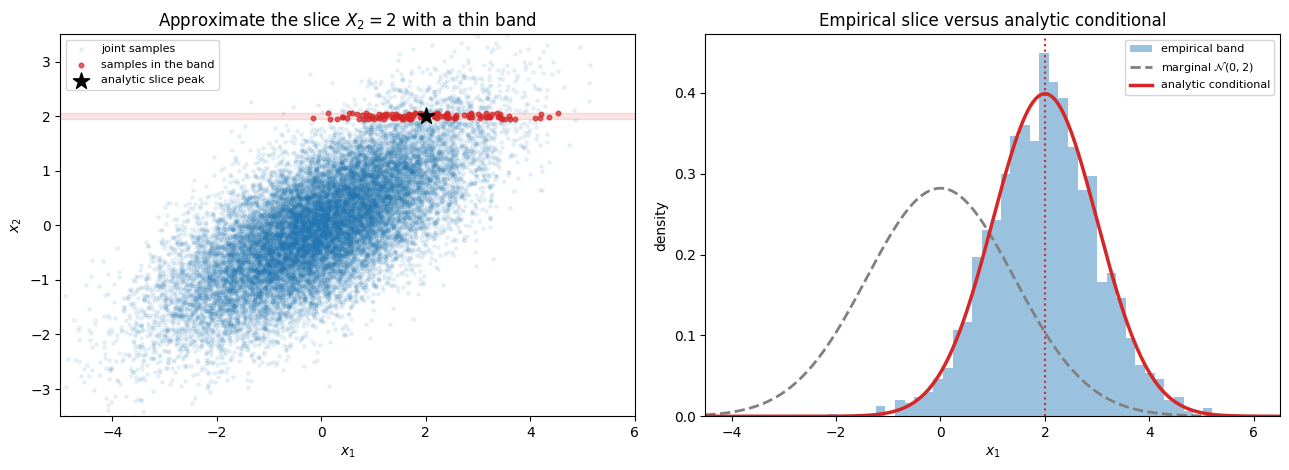

In [14]:
def normal_pdf(values, mean, variance):
    '''Evaluate a univariate Gaussian density.'''
    values = np.asarray(values, dtype=float)
    scale = np.sqrt(2.0 * np.pi * variance)
    return np.exp(-0.5 * (values - mean) ** 2 / variance) / scale


condition_plot_count = 20_000
plot_samples = samples[:condition_plot_count]
plot_slice_mask = np.abs(plot_samples[:, 1] - x2_observed) <= bandwidth
x1_line = np.linspace(-4.5, 6.5, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(
    plot_samples[:, 0],
    plot_samples[:, 1],
    s=6,
    alpha=0.08,
    color="tab:blue",
    label="joint samples",
)
axes[0].scatter(
    plot_samples[plot_slice_mask, 0],
    plot_samples[plot_slice_mask, 1],
    s=11,
    alpha=0.7,
    color="tab:red",
    label="samples in the band",
)
axes[0].axhspan(
    x2_observed - bandwidth,
    x2_observed + bandwidth,
    color="tab:red",
    alpha=0.12,
)
axes[0].scatter(
    [2.0],
    [2.0],
    marker="*",
    s=150,
    color="black",
    label="analytic slice peak",
)
axes[0].set(
    title=r"Approximate the slice $X_2=2$ with a thin band",
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xlim=(-5.0, 6.0),
    ylim=(-3.5, 3.5),
)
axes[0].legend(fontsize=8)

axes[1].hist(
    x1_slice,
    bins=40,
    density=True,
    alpha=0.45,
    color="tab:blue",
    label="empirical band",
)
axes[1].plot(
    x1_line,
    normal_pdf(x1_line, mean=0.0, variance=2.0),
    color="gray",
    linestyle="--",
    linewidth=2,
    label=r"marginal $\mathcal{N}(0,2)$",
)

if np.isfinite(conditional_mean).all() and np.isfinite(conditional_cov).all():
    axes[1].plot(
        x1_line,
        normal_pdf(
            x1_line,
            mean=float(conditional_mean[0]),
            variance=float(conditional_cov[0, 0]),
        ),
        color="tab:red",
        linewidth=2.5,
        label=r"analytic conditional",
    )
    axes[1].axvline(
        float(conditional_mean[0]),
        color="tab:red",
        linestyle=":",
        linewidth=1.5,
    )
else:
    axes[1].text(
        0.98,
        0.92,
        "Analytic conditional\nparameters are unavailable",
        transform=axes[1].transAxes,
        ha="right",
        va="top",
    )

axes[1].set(
    title="Empirical slice versus analytic conditional",
    xlabel=r"$x_1$",
    ylabel="density",
    xlim=(-4.5, 6.5),
)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


In [15]:
if np.isfinite(conditional_mean).all() and np.isfinite(conditional_cov).all():
    mean_error = abs(empirical_conditional_mean - conditional_mean[0])
    variance_error = abs(
        empirical_conditional_variance - conditional_cov[0, 0]
    )

    assert mean_error < 0.08
    assert variance_error < 0.12

    print(f"analytic mean: {conditional_mean[0]:.6f}")
    print(f"empirical mean: {empirical_conditional_mean:.6f}")
    print(f"absolute mean error: {mean_error:.6f}")
    print(f"analytic variance: {conditional_cov[0, 0]:.6f}")
    print(f"empirical variance: {empirical_conditional_variance:.6f}")
    print(f"absolute variance error: {variance_error:.6f}")
else:
    print("The conditional comparison contains non-finite values.")


analytic mean: 2.000000
empirical mean: 1.983336
absolute mean error: 0.016664
analytic variance: 1.000000
empirical variance: 1.017204
absolute variance error: 0.017204


**Checkpoint 4.** The empirical values should be close, but not identical,
to $2$ and $1$. The remaining difference combines Monte Carlo error with
the fact that the band conditions on $X_2\approx2$, not exactly $2$.


---

## 5. Diffusion contact

A DDPM forward-noising kernel is a Gaussian:

$$
q(x_t\mid x_0)
=
\mathcal{N}\left(
\sqrt{\bar\alpha_t}\,x_0,
(1-\bar\alpha_t)I
\right).
$$

Substitute its mean and covariance into the general Gaussian score:

$$
\nabla_{x_t}\log q(x_t\mid x_0)
=
-\frac{x_t-\sqrt{\bar\alpha_t}\,x_0}
{1-\bar\alpha_t}.
$$

The next cell checks this substitution against your generic score
implementation.


In [16]:
alpha_bar_t = 0.64
x0 = np.array([1.0, -0.5])
forward_mean = np.sqrt(alpha_bar_t) * x0
forward_cov = (1.0 - alpha_bar_t) * np.eye(2)
x_t = forward_mean + np.array([0.30, -0.20])

forward_score_closed_form = -(x_t - forward_mean) / (1.0 - alpha_bar_t)
forward_score_generic = gaussian_score(x_t, forward_mean, forward_cov)

if np.isfinite(forward_score_generic).all():
    assert np.allclose(forward_score_generic, forward_score_closed_form)
    print("forward mean:", forward_mean)
    print("x_t:", x_t)
    print("score from Gaussian helper:", forward_score_generic)
    print("score from DDPM form:", forward_score_closed_form)
else:
    print("The generic Gaussian score returned non-finite values.")


forward mean: [ 0.8 -0.4]
x_t: [ 1.1 -0.6]
score from Gaussian helper: [-0.8333  0.5556]
score from DDPM form: [-0.8333  0.5556]


---

## Findings

1. The Cholesky factor satisfied $LL^\top=\Sigma$, and samples generated as $X=\mu+LZ$ had an empirical mean close to $(0,0)^\top$ and covariance entries within $0.0033$ of their targets, supporting the construction up to Monte Carlo error.
2. The central finite-difference approximation to $\nabla_x\log p(x)$ agreed with the analytic score at every tested point, with a maximum error of about $6.35\times10^{-11}$; this independently checked the implementation's signs, transposes, and matrix operations, although it is not a formal proof for every $x$.
3. Because $P(X_2=2)=0$ for a continuous variable, the empirical conditional used the finite band $|X_2-2|\le0.06$, introducing both finite-band approximation and Monte Carlo error; in this jointly Gaussian example, conditioning subtracts the positive-semidefinite term $\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$, reducing the variance from $2$ to $1$, while the empirical estimate was $1.0172$.
4. To obtain the forward-noising conditional score, substitute $x=x_t$, $\mu=\sqrt{\bar\alpha_t}\,x_0$, and $\Sigma=(1-\bar\alpha_t)I$ into the general Gaussian score; since $\Sigma^{-1}=(1-\bar\alpha_t)^{-1}I$, this gives $\nabla_{x_t}\log q(x_t\mid x_0)=-(x_t-\sqrt{\bar\alpha_t}\,x_0)/(1-\bar\alpha_t)$.

**Week 10 conclusion:** the analytic Gaussian identities, their numerical
checks, and their diffusion specialization agree.
